
===== TEST SET PREDICTIONS =====
[1 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 1 0 1 0 1 0 0 0 1 0
 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 1 0 1 0 0 0 1 1 1 0 1 0 0 0
 0 1 0 1 1 0 0 1 1 0 0 0 1 0 1 1 1 0 1 0 1 1 0 0 1 1 0 1 0 0 1 1 0 0 1 0 0
 1 0 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 1
 1 0 0 1 0 0 0 1 0 0 1 1 0 1 1 0 0 0 0 0 0 1 0 0 0 0 1 1 1 0 0]

===== MODEL ACCURACY =====
Accuracy = 0.8045
Accuracy = 80.45%

===== CONFUSION MATRIX =====
[[93 12]
 [23 51]]

===== CONFUSION MATRIX BREAKDOWN =====
True Negatives  (TN): 93
False Positives (FP): 12
False Negatives (FN): 23
True Positives  (TP): 51

===== FEATURE IMPORTANCE =====
Pclass     : 0.0825
Sex        : 0.2598
Age        : 0.2578
SibSp      : 0.0481
Parch      : 0.0382
Fare       : 0.2756
Embarked   : 0.0380


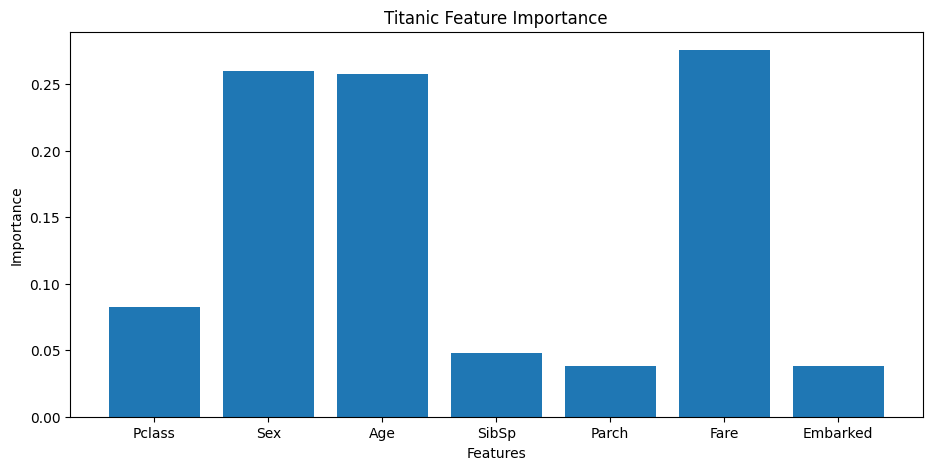

In [13]:
import pandas as pd

# =========================
# LOAD DATA
# =========================

df = pd.read_csv("train.csv")

# =========================
# DATA CLEANING
# =========================

df["Age"] = df["Age"].fillna(df["Age"].median())

df["Embarked"] = df["Embarked"].fillna(
    df["Embarked"].mode()[0]
)

df = df.drop(columns=["Cabin"])

# =========================
# ENCODE CATEGORICAL DATA
# =========================

df["Sex"] = df["Sex"].map({
    "male": 0,
    "female": 1
})

df["Embarked"] = df["Embarked"].map({
    "S": 0,
    "C": 1,
    "Q": 2
})

# =========================
# FEATURE SELECTION
# =========================

features = [
    "Pclass",
    "Sex",
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "Embarked"
]

X = df[features]
y = df["Survived"]

# =========================
# TRAIN TEST SPLIT
# =========================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=21
)

# =========================
# RANDOM FOREST MODEL
# =========================

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=21
)

model.fit(X_train, y_train)

# =========================
# PREDICTIONS
# =========================

y_pred = model.predict(X_test)

print("\n===== TEST SET PREDICTIONS =====")
print(y_pred)

# =========================
# ACCURACY
# =========================

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("\n===== MODEL ACCURACY =====")
print(f"Accuracy = {accuracy:.4f}")
print(f"Accuracy = {accuracy * 100:.2f}%")

# =========================
# CONFUSION MATRIX
# =========================

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("\n===== CONFUSION MATRIX =====")
print(cm)

print("\n===== CONFUSION MATRIX BREAKDOWN =====")
print(f"True Negatives  (TN): {cm[0][0]}")
print(f"False Positives (FP): {cm[0][1]}")
print(f"False Negatives (FN): {cm[1][0]}")
print(f"True Positives  (TP): {cm[1][1]}")

# =========================
# FEATURE IMPORTANCE
# =========================

print("\n===== FEATURE IMPORTANCE =====")

importance = model.feature_importances_

for feature, score in zip(features, importance):
    print(f"{feature:<10} : {score:.4f}")

# =========================
# FEATURE IMPORTANCE PLOT
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))

plt.bar(
    features,
    model.feature_importances_
)

plt.title("Titanic Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()